EXPLORATORY DATA ANALYSIS OF THE REAL ESTATE MARKET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("district_prices_monthly.csv")

In [3]:
df.head()

,year_month,district,okrug,secondary_price_per_sqm,newbuild_price_per_sqm,rental_price_per_sqm_monthly,secondary_mom_change_pct,newbuild_mom_change_pct,n_listings_secondary,n_listings_newbuild,n_listings_rental,cbr_key_rate_pct,avg_mortgage_rate_pct
0,2020-01,Arbat,CAO,480000,543700,2000,NaN,NaN,104,68,41,6.00,8.50
1,2020-02,Arbat,CAO,469100,531500,1955,-2.28,-2.24,22,63,50,6.00,8.50
2,2020-03,Arbat,CAO,502200,559800,2093,7.07,5.33,104,56,28,6.00,8.50
3,2020-04,Arbat,CAO,505100,541500,2104,0.56,-3.27,168,29,107,4.25,6.75
4,2020-05,Arbat,CAO,523500,594800,2181,3.65,9.84,66,58,57,4.25,6.75


In [4]:
df.shape

(9804, 13)

In [5]:
df.columns

Index(['year_month', 'district', 'okrug', 'secondary_price_per_sqm',
       'newbuild_price_per_sqm', 'rental_price_per_sqm_monthly',
       'secondary_mom_change_pct', 'newbuild_mom_change_pct',
       'n_listings_secondary', 'n_listings_newbuild', 'n_listings_rental',
       'cbr_key_rate_pct', 'avg_mortgage_rate_pct'],
      dtype='object')

In [6]:
df.rename(columns={
    'secondary_price_per_sqm': 'secondary_price',
    'newbuild_price_per_sqm': 'newbuild_price',
    'rental_price_per_sqm_monthly': 'rental_price',
    'secondary_mom_change_pct': 'secondary_change_pct',
    'newbuild_mom_change_pct': 'newbuild_change_pct',
    'n_listings_secondary': 'secondary_listings',
    'n_listings_newbuild': 'newbuild_listings',
    'n_listings_rental': 'rental_listings',
    'cbr_key_rate_pct': 'key_rate',
    'avg_mortgage_rate_pct': 'mortgage_rate'
}, inplace=True)

In [7]:
df.columns

Index(['year_month', 'district', 'okrug', 'secondary_price', 'newbuild_price',
       'rental_price', 'secondary_change_pct', 'newbuild_change_pct',
       'secondary_listings', 'newbuild_listings', 'rental_listings',
       'key_rate', 'mortgage_rate'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year_month            9804 non-null   object 
 1   district              9804 non-null   object 
 2   okrug                 9804 non-null   object 
 3   secondary_price       9804 non-null   int64  
 4   newbuild_price        9804 non-null   int64  
 5   rental_price          9804 non-null   int64  
 6   secondary_change_pct  9675 non-null   float64
 7   newbuild_change_pct   9675 non-null   float64
 8   secondary_listings    9804 non-null   int64  
 9   newbuild_listings     9804 non-null   int64  
 10  rental_listings       9804 non-null   int64  
 11  key_rate              9804 non-null   float64
 12  mortgage_rate         9804 non-null   float64
dtypes: float64(4), int64(6), object(3)
memory usage: 995.8+ KB


In [9]:
df['year_month'] = pd.to_datetime(df['year_month'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   year_month            9804 non-null   datetime64[ns]
 1   district              9804 non-null   object        
 2   okrug                 9804 non-null   object        
 3   secondary_price       9804 non-null   int64         
 4   newbuild_price        9804 non-null   int64         
 5   rental_price          9804 non-null   int64         
 6   secondary_change_pct  9675 non-null   float64       
 7   newbuild_change_pct   9675 non-null   float64       
 8   secondary_listings    9804 non-null   int64         
 9   newbuild_listings     9804 non-null   int64         
 10  rental_listings       9804 non-null   int64         
 11  key_rate              9804 non-null   float64       
 12  mortgage_rate         9804 non-null   float64       
dtypes: datetime64[ns](

In [11]:
df.describe()

,year_month,secondary_price,newbuild_price,rental_price,secondary_change_pct,newbuild_change_pct,secondary_listings,newbuild_listings,rental_listings,key_rate,mortgage_rate
count,9804,9804.000000,9804.000000,9804.000000,9675.000000,9675.000000,9804.000000,9804.000000,9804.000000,9804.000000,9804.000000
mean,2023-02-15 03:47:22.105263360,293669.543044,323147.460220,1223.625051,0.653792,0.713295,109.478070,42.461444,64.638821,11.986842,14.486842
min,2020-01-01 00:00:00,70600.000000,74700.000000,294.000000,-13.090000,-15.630000,20.000000,5.000000,10.000000,4.250000,6.750000
25%,2021-07-24 06:00:00,220400.000000,242375.000000,918.000000,-1.890000,-2.820000,64.000000,24.000000,38.000000,7.500000,10.000000
50%,2023-02-15 00:00:00,274200.000000,301000.000000,1142.500000,0.600000,0.520000,110.000000,43.000000,65.000000,9.500000,12.000000
75%,2024-09-08 12:00:00,344600.000000,379000.000000,1436.000000,3.130000,4.150000,155.000000,61.000000,92.000000,17.000000,19.500000
max,2026-04-01 00:00:00,812700.000000,924900.000000,3386.000000,15.740000,25.910000,199.000000,79.000000,119.000000,21.000000,23.500000
std,NaN,123593.449575,136415.279338,514.966664,3.693047,5.149745,52.000534,21.655502,31.757889,5.712394,5.712394


In [12]:
df.isnull().sum()

year_month                0
district                  0
okrug                     0
secondary_price           0
newbuild_price            0
rental_price              0
secondary_change_pct    129
newbuild_change_pct     129
secondary_listings        0
newbuild_listings         0
rental_listings           0
key_rate                  0
mortgage_rate             0
dtype: int64

In [13]:
df['secondary_change_pct'].fillna(0, inplace=True)
df['newbuild_change_pct'].fillna(0, inplace=True)

C:\Users\DIPESH DUBEY\AppData\Local\Temp\ipykernel_17772\1565716437.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['secondary_change_pct'].fillna(0, inplace=True)
C:\Users\DIPESH DUBEY\AppData\Local\Temp\ipykernel_17772\1565716437.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [14]:
df.isnull().sum()

year_month              0
district                0
okrug                   0
secondary_price         0
newbuild_price          0
rental_price            0
secondary_change_pct    0
newbuild_change_pct     0
secondary_listings      0
newbuild_listings       0
rental_listings         0
key_rate                0
mortgage_rate           0
dtype: int64

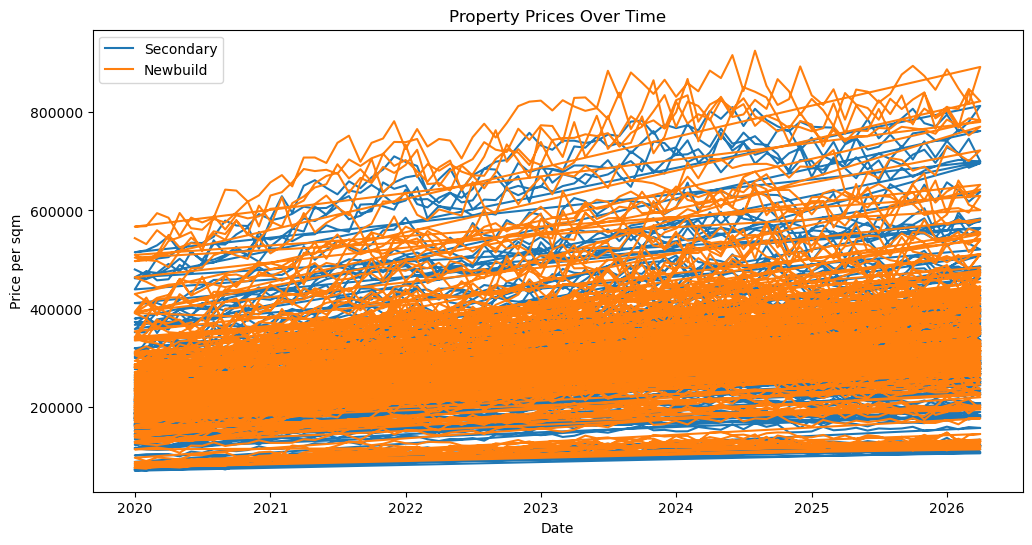

In [15]:
plt.figure(figsize=(12,6))

plt.plot(df['year_month'], df['secondary_price'], label='Secondary')
plt.plot(df['year_month'], df['newbuild_price'], label='Newbuild')

plt.xlabel('Date')
plt.ylabel('Price per sqm')
plt.title('Property Prices Over Time')

plt.legend()
plt.show()

The time-series visualization indicates that both secondary and newbuild property prices generally increased over time. 

Newbuild properties consistently show higher prices compared to secondary properties across most periods. 

Although price fluctuations are visible across districts, the overall market trend demonstrates long-term growth in property values from 2020 to 2026.

The graph also suggests substantial variability in housing prices among different districts, indicating geographic differences in market demand and property valuation.

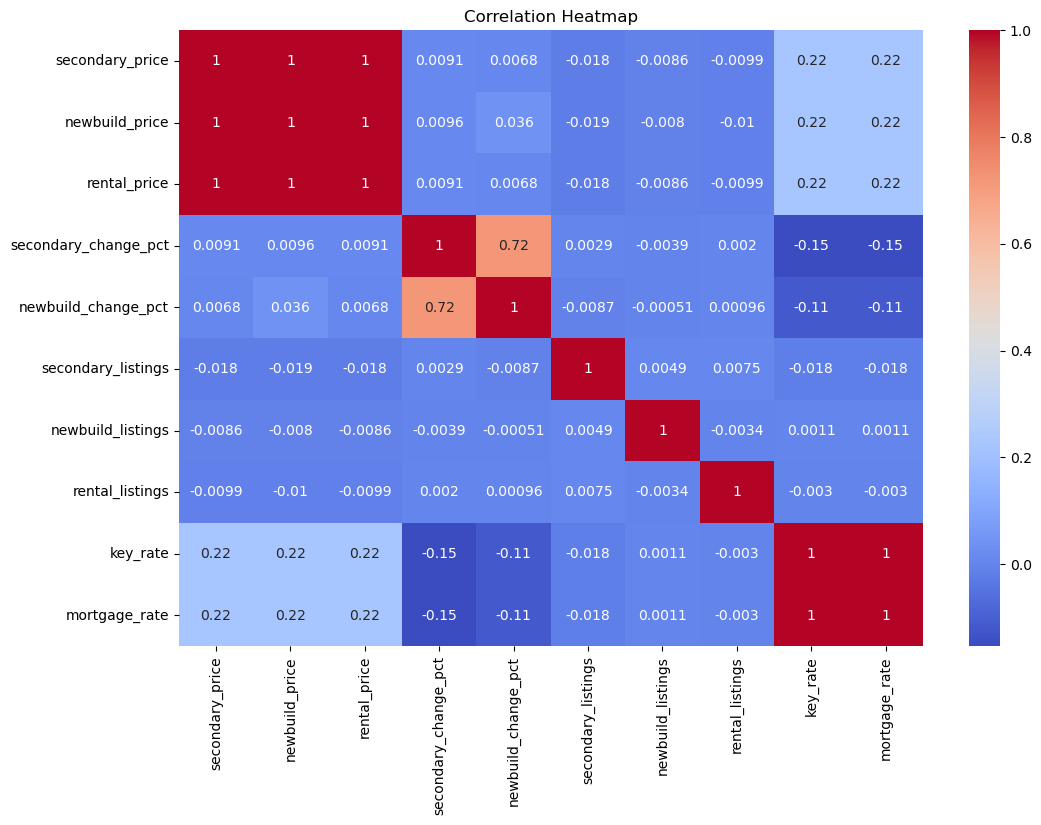

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

The correlation heatmap reveals a very strong positive correlation between:
- secondary_price
- newbuild_price
- rental_price

This indicates that all property price categories tend to increase and decrease together.

The month-on-month percentage change variables also show a strong positive correlation (0.72), suggesting similar movement patterns between secondary and newbuild markets.

The key interest rate and mortgage rate have a perfect positive correlation, indicating that mortgage rates closely follow central bank policy rates.

Listing-related variables show very weak correlations with prices, suggesting that listing volume alone may not strongly influence property prices.

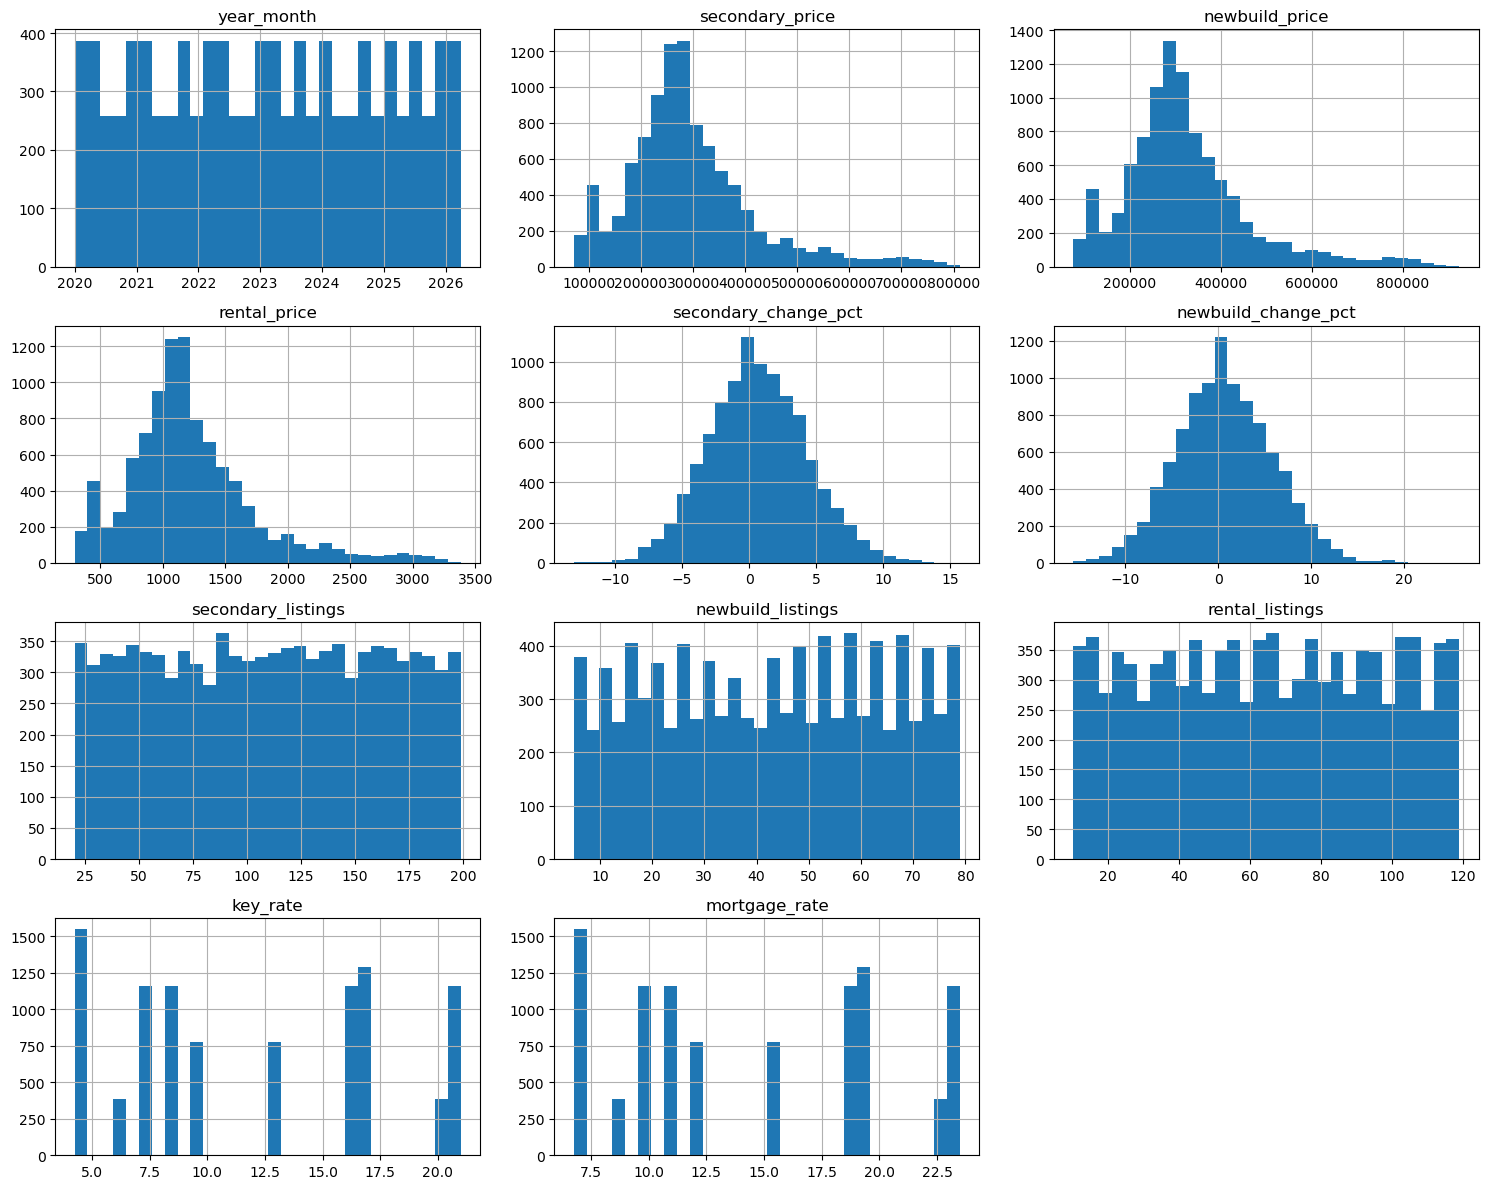

In [17]:
df.hist(figsize=(15,12), bins=30)

plt.tight_layout()

plt.show()

The price-related variables (secondary_price, newbuild_price, and rental_price) show right-skewed distributions. Most properties fall within lower-to-middle price ranges, while a smaller number of properties have extremely high prices.

The month-on-month percentage change variables approximately follow a normal distribution centered around 0, indicating that most monthly changes are relatively small.

Listing-related variables appear more uniformly distributed across districts.

Interest rate variables (key_rate and mortgage_rate) show clustered distributions because interest rates change only during specific economic policy periods.

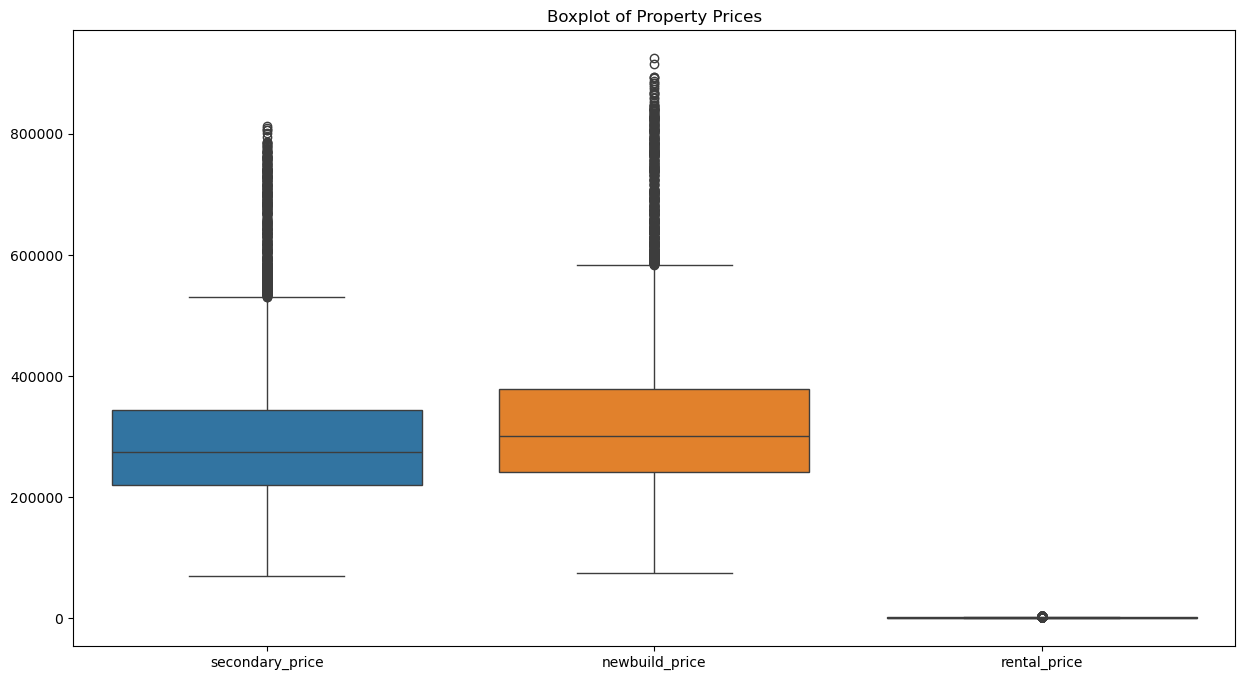

In [18]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df[['secondary_price',
                     'newbuild_price',
                     'rental_price']])

plt.title('Boxplot of Property Prices')

plt.show()

The boxplots reveal the presence of multiple outliers in:
- secondary_price
- newbuild_price

These outliers represent extremely high-priced properties that differ significantly from the majority of observations.

Newbuild properties generally have higher median prices and greater variability compared to secondary properties.

Rental prices appear much smaller in scale compared to property sale prices, causing the rental boxplot to appear compressed.

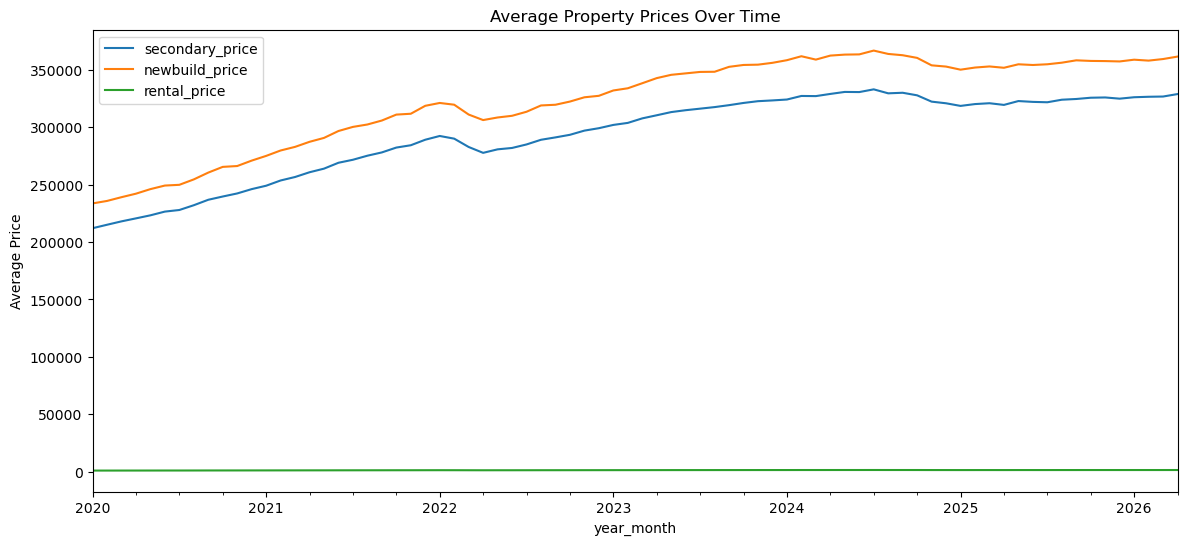

In [19]:
plt.figure(figsize=(14,6))

monthly_trend = df.groupby('year_month')[
    ['secondary_price', 'newbuild_price', 'rental_price']
].mean()

monthly_trend.plot(ax=plt.gca())

plt.title('Average Property Prices Over Time')

plt.ylabel('Average Price')

plt.show()

The time-series analysis shows a clear upward trend in both secondary and newbuild property prices from 2020 to 2026.

Newbuild properties consistently maintain higher average prices than secondary properties throughout the observed period.

A slight decline or stabilization in prices is visible around 2024–2025, after which prices continue to stabilize.

Rental prices remain relatively stable and significantly lower compared to property sale prices.

A temporary slowdown in price growth may indicate market correction or the impact of changing economic conditions such as mortgage and interest rate fluctuations.

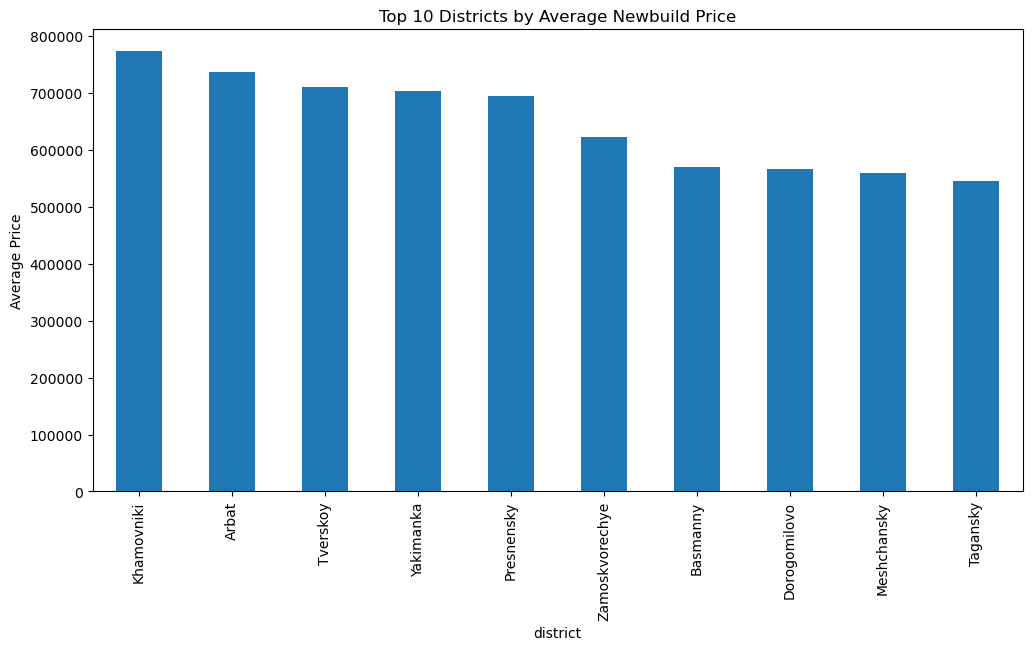

In [20]:
top_districts = df.groupby('district')['newbuild_price'] \
                  .mean() \
                  .sort_values(ascending=False) \
                  .head(10)

plt.figure(figsize=(12,6))

top_districts.plot(kind='bar')

plt.title('Top 10 Districts by Average Newbuild Price')

plt.ylabel('Average Price')

plt.show()

The district-wise analysis reveals significant variation in property prices across districts.

Khamovniki has the highest average newbuild property prices, followed by Arbat and Tverskoy.

These districts are likely premium urban areas with higher demand, better infrastructure, and stronger economic activity.

The results indicate clear geographic inequality in housing prices across districts.

In [21]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    df['secondary_price'],
    df['newbuild_price']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -15.856163015002469
P-value: 2.8521506361085266e-56


A two-sample t-test was conducted to compare secondary property prices and newbuild property prices.

Results:
- T-statistic = -15.86
- P-value ≈ 0.000

Since the p-value is far below 0.05, the null hypothesis is rejected.

This indicates that there is a statistically significant difference between secondary and newbuild property prices.

The exploratory data analysis identified several important trends and patterns in the housing market dataset.

Property prices showed a consistent upward trend over time, with newbuild properties remaining more expensive than secondary properties across all periods.

Strong positive correlations were observed among different property price categories, indicating interconnected market behavior.

Outlier analysis revealed the presence of high-value luxury properties, particularly within newbuild markets.

District-level analysis demonstrated substantial geographic variation in housing prices, with premium districts such as Khamovniki and Arbat exhibiting the highest average prices.

Statistical hypothesis testing confirmed that the difference between secondary and newbuild property prices is statistically significant.

Overall, the dataset appears clean, structured, and suitable for deeper predictive or economic analysis.